# Credit Risk Prediction System – End-to-End ML Model with Deployment

**Machine Learning Capstone Project**

This notebook builds a complete, end-to-end machine learning system that
classifies loan applicants as **High Risk** or **Low Risk**, following the
workflow: data understanding → cleaning → preprocessing → feature
engineering → EDA → train/test split → model training → hyperparameter
tuning → evaluation → model selection → model saving → Streamlit
deployment.

## Problem Statement

Lenders need to assess, before approving a loan, how likely an applicant is
to represent a credit risk. Manually reviewing every applicant's full
financial profile does not scale. We build a supervised classification model
that uses an applicant's financial and demographic information to predict a
binary risk category, which can support (not replace) a human underwriter's
decision.

## Objective

Build and deploy a classification model that predicts whether a loan
applicant is **High Risk** or **Low Risk**, using only information that is
realistically available *before* a lending decision is made, while avoiding
data leakage and following sound ML engineering practice (proper
train/test separation, pipelines, cross-validated tuning).

## 4. Import Libraries

In [1]:
import sys
sys.path.append("..")  # so feature_engineering.py (project root) is importable

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

from feature_engineering import add_engineered_features

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
PLOTS_DIR = "../outputs/plots"
MODELS_DIR = "../models"


## 5. Load Dataset

In [2]:
df = pd.read_csv("../data/Loan.csv")
print("Shape:", df.shape)
df.head()

Shape: (20000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


## 6. Data Understanding

We inspect the actual dataset (shape, dtypes, numeric/categorical columns,
descriptive statistics) rather than assuming any structure in advance.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (20000, 36)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRa

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


In [5]:
numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_all = df.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric columns:", numeric_cols_all)
print("\nCategorical columns:", categorical_cols_all)

Numeric columns: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical columns: ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


In [6]:
for c in ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']:
    print(c, ':', df[c].unique())

EmploymentStatus : <ArrowStringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str
EducationLevel : <ArrowStringArray>
['Master', 'Associate', 'Bachelor', 'High School', 'Doctorate']
Length: 5, dtype: str
MaritalStatus : <ArrowStringArray>
['Married', 'Single', 'Divorced', 'Widowed']
Length: 4, dtype: str
HomeOwnershipStatus : <ArrowStringArray>
['Own', 'Mortgage', 'Rent', 'Other']
Length: 4, dtype: str
LoanPurpose : <ArrowStringArray>
['Home', 'Debt Consolidation', 'Education', 'Other', 'Auto']
Length: 5, dtype: str


**Why binary classification?** The Enginow specification requires predicting
`Risk (High/Low)` — a two-class label. Once we define this target (Section 8),
the task is a standard binary classification problem: assign each applicant
to one of exactly two mutually exclusive classes.

## 7. Data Quality Check

In [7]:
missing = df.isnull().sum()
print("Missing values per column (only columns with >0 shown):")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column (only columns with >0 shown):
No missing values found.



Duplicate rows: 0


The dataset has **no missing values** and **no duplicate rows**. This is a
clean, complete dataset, so no row deletion or advanced imputation for
missingness is required at the raw-data level (imputers are still included
in the pipeline as a safety net and best practice).

## 8. Target Selection — Investigation

The Enginow spec requires a target representing **Risk (High/Low)**. The raw
dataset offers two related candidates: `RiskScore` (continuous) and
`LoanApproved` (binary). We investigate both before choosing.

In [8]:
print("RiskScore summary:")
print(df['RiskScore'].describe())
print()
print("LoanApproved value counts:")
print(df['LoanApproved'].value_counts())
print()
print("Correlation(RiskScore, LoanApproved):", df['RiskScore'].corr(df['LoanApproved']))

RiskScore summary:
count    20000.000000
mean        50.766780
std          7.778262
min         28.800000
25%         46.000000
50%         52.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64

LoanApproved value counts:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Correlation(RiskScore, LoanApproved): -0.7661374114914389


In [9]:
# Is LoanApproved simply a threshold rule applied to RiskScore?
best_thresh, best_acc = None, 0
for t in range(20, 90):
    acc = ((df['RiskScore'] < t).astype(int) == df['LoanApproved']).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t
print(f"Best single threshold on RiskScore reproduces LoanApproved with accuracy = {best_acc:.4f} at threshold {best_thresh}")

Best single threshold on RiskScore reproduces LoanApproved with accuracy = 0.9653 at threshold 45


**Findings:**
- A simple rule *"Approved if RiskScore < ~45"* reproduces `LoanApproved` with
  ~96.5% accuracy. This shows `LoanApproved` is **downstream of / derived
  from** `RiskScore` (an approval decision made largely from the risk score),
  not an independent signal.
- `LoanApproved` represents a **post-decision** business outcome (whether the
  loan was approved), not risk itself. Using it as the target would answer
  "will this application be approved?" rather than "is this applicant risky?"
  and would still be circular with `RiskScore`.
- `RiskScore` is the dataset's native, continuous **risk measurement**, and is
  the most direct available proxy for the "Risk (High/Low)" label the spec
  requires.

**Target Decision:** We binarize `RiskScore` using a **median split**:

```
High Risk = RiskScore >= median(RiskScore)
Low  Risk = RiskScore <  median(RiskScore)
```

**Why median split:** it is simple, reproducible, requires no arbitrary
business threshold, and (as shown below) yields a naturally balanced target
— avoiding the need for artificial class-balancing tricks.

**Why alternatives were rejected:**
- `LoanApproved` as target — rejected because it reflects a post-decision
  approval outcome derived mostly from `RiskScore`, not risk itself.
- An arbitrary fixed RiskScore cutoff (e.g. "high risk if RiskScore > 60") —
  rejected in favor of the median split, which is data-driven rather than
  hand-picked.

**Limitation (documented):** `RiskScore` itself is very likely a formula
computed from a combination of the applicant's financial features (income,
net worth, debt ratios, bankruptcy history, etc. — see the leakage analysis
below). This means the model is, to a meaningful extent, learning to
approximate that pre-existing scoring formula rather than discovering an
entirely independent notion of risk. This is a known and disclosed
limitation of using a dataset where the "ground truth" risk label is itself
model/rule-derived rather than an observed real-world outcome (e.g. actual
default).

In [10]:
RISK_MEDIAN = df['RiskScore'].median()
df['RiskLabel'] = np.where(df['RiskScore'] >= RISK_MEDIAN, 'High Risk', 'Low Risk')
print("Median RiskScore threshold:", RISK_MEDIAN)
print(df['RiskLabel'].value_counts())
print(df['RiskLabel'].value_counts(normalize=True) * 100)

Median RiskScore threshold: 52.0
RiskLabel
High Risk    10168
Low Risk      9832
Name: count, dtype: int64
RiskLabel
High Risk    50.84
Low Risk     49.16
Name: proportion, dtype: float64


## 9. Data Leakage Analysis

**Target-derived leakage:**
- `RiskScore` is used to construct the target → **must be dropped** as a
  feature (it would trivially leak the label).
- `LoanApproved` is strongly derived from `RiskScore` (~96.5% reproducible
  via a simple threshold) and represents a post-decision outcome →
  **also dropped**.

**Other columns checked:** No other column in the dataset directly encodes
the target or is a duplicate of it.

**Procedural leakage prevention (enforced throughout this notebook):**
- Train/test split is performed **before** any preprocessing, scaling,
  encoding, feature-selection, or SMOTE.
- All preprocessing (imputation, scaling, one-hot encoding) is wrapped in a
  single `sklearn`/`imblearn` `Pipeline`, fit **only** on training folds.
- SMOTE (if used) is placed inside the pipeline so it is applied only to
  training folds during cross-validation, never to the test set.
- Hyperparameter tuning uses cross-validation on the training set only; the
  test set is touched exactly once, for final evaluation.

`ApplicationDate` is also dropped — inspection showed dates spanning an
unrealistic range (into the 2070s), indicating it is a synthetic field with
no genuine temporal predictive meaning here.

In [11]:
LEAKY_COLS = ['RiskScore', 'LoanApproved']
DROP_COLS = ['ApplicationDate']
print(df['ApplicationDate'].min(), '->', df['ApplicationDate'].max())

2018-01-01 -> 2072-10-03


## 10. Data Preprocessing

We build a `ColumnTransformer` that:
- Imputes numeric columns with the **median** and scales them with
  `StandardScaler`.
- Imputes categorical columns with the **most frequent** value and encodes
  them with `OneHotEncoder(handle_unknown="ignore")`.

All fitting happens inside the pipeline, only on the training set (Section
13), so there is no leakage from test data into scaling/encoding.

In [12]:
for c in numeric_cols_all:
    if c not in ('RiskScore', 'LoanApproved'):
        pass
numeric_cols_all = [c for c in numeric_cols_all if c not in ('RiskScore', 'LoanApproved')]
categorical_cols_all = [c for c in categorical_cols_all if c not in ('RiskLabel',)]
print("Numeric feature candidates:", numeric_cols_all)
print("Categorical feature candidates:", categorical_cols_all)

Numeric feature candidates: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
Categorical feature candidates: ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


### Outlier Investigation (IQR)

We check for outliers using the IQR method on key numeric columns, but do
**not** automatically delete them: in a credit-risk context, unusually high
income/assets or low credit scores are genuine, informative data points, not
measurement errors. Tree-based models (Random Forest / Gradient Boosting /
XGBoost) are also naturally robust to such outliers.

In [13]:
outlier_report = {}
for col in ['AnnualIncome', 'LoanAmount', 'TotalAssets', 'TotalLiabilities', 'CreditScore']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {'lower': round(lower, 2), 'upper': round(upper, 2), 'n_outliers': int(n_out)}
pd.DataFrame(outlier_report).T

,lower,upper,n_outliers
AnnualIncome,-32389.00,138459.00,947.0
LoanAmount,-7315.00,53725.00,746.0
TotalAssets,-98157.25,246742.75,1442.0
TotalLiabilities,-36727.88,91071.12,1533.0
CreditScore,436.50,712.50,242.0


**Decision:** outliers are retained (no rows removed) for the reasons above.

## 11. Feature Engineering

The dataset already contains `DebtToIncomeRatio` and `TotalDebtToIncomeRatio`.
We inspect rather than blindly recompute a duplicate ratio.

In [14]:
check = (df['MonthlyDebtPayments'] / df['MonthlyIncome'].replace(0, np.nan)).head()
print("MonthlyDebtPayments/MonthlyIncome (manual):", check.values)
print("Existing DebtToIncomeRatio column:          ", df['DebtToIncomeRatio'].head().values)

MonthlyDebtPayments/MonthlyIncome (manual): [0.05497146 0.14989045 0.26578922 0.13114469 0.03184072]
Existing DebtToIncomeRatio column:           [0.3583356  0.33027367 0.24472911 0.43624427 0.07888421]


The existing `DebtToIncomeRatio` does not match a naive
`MonthlyDebtPayments / MonthlyIncome` computation exactly (it likely factors
in additional obligations), so we **use the existing column as-is** rather
than overwriting it with a duplicate/simplified formula.

**New engineered features:**

1. **TotalObligationRatio** = `(TotalLiabilities + MonthlyLoanPayment) / (12 * MonthlyIncome + 1)`
   — captures total financial burden (existing liabilities plus the new
   loan's repayment) relative to annual income capacity. The `+1` in the
   denominator prevents division by zero.
2. **AgeGroup** — `Young` (<=30), `Middle-aged` (31-50), `Senior` (51+),
   chosen as standard, easily interpretable life-stage boundaries.

(Implemented in `feature_engineering.py` so training and the deployed
Streamlit app compute these identically.)

In [15]:
df = add_engineered_features(df)
numeric_cols_all = numeric_cols_all + ['TotalObligationRatio']
categorical_cols_all = categorical_cols_all + ['AgeGroup']
df[['TotalObligationRatio', 'AgeGroup']].describe(include='all')

,TotalObligationRatio,AgeGroup
count,20000.000000,20000
unique,NaN,3
top,NaN,Middle-aged
freq,NaN,11871
mean,0.910490,NaN
std,1.415897,NaN
min,0.004878,NaN
25%,0.222517,NaN
50%,0.477213,NaN
75%,1.040941,NaN


In [16]:
df['AgeGroup'].value_counts()

AgeGroup
Middle-aged    11871
Young           4501
Senior          3628
Name: count, dtype: int64

## 12. Exploratory Data Analysis

Key visual insights required by the spec: risk distribution, risk vs.
age/income/employment/credit score, correlation heatmap, boxplots, and
distribution plots. Plots are saved to `outputs/plots/`.

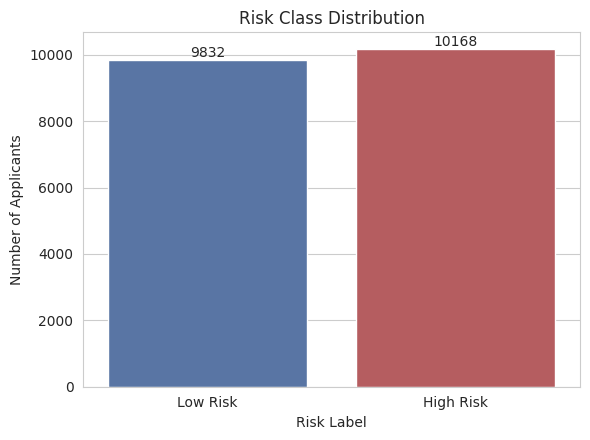

In [17]:
order = ['Low Risk', 'High Risk']
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='RiskLabel', data=df, order=order, palette=['#4C72B0', '#C44E52'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.title('Risk Class Distribution'); plt.xlabel('Risk Label'); plt.ylabel('Number of Applicants')
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/risk_distribution.png'); plt.show()

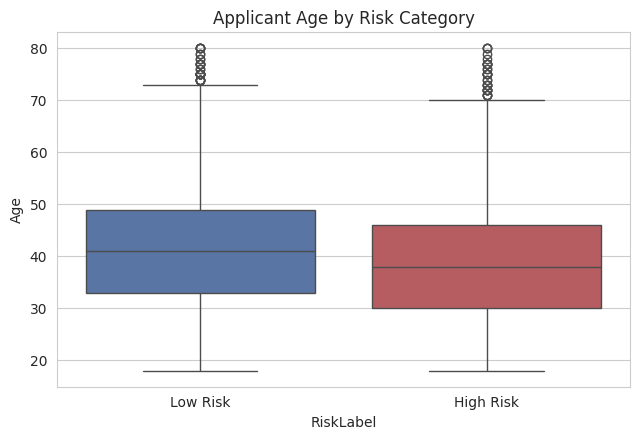

In [18]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x='RiskLabel', y='Age', data=df, order=order, palette=['#4C72B0', '#C44E52'])
plt.title('Applicant Age by Risk Category'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/risk_by_age.png'); plt.show()

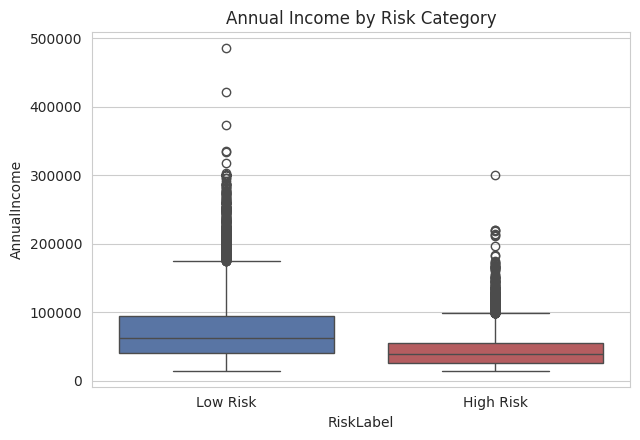

In [19]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x='RiskLabel', y='AnnualIncome', data=df, order=order, palette=['#4C72B0', '#C44E52'])
plt.title('Annual Income by Risk Category'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/risk_by_income.png'); plt.show()

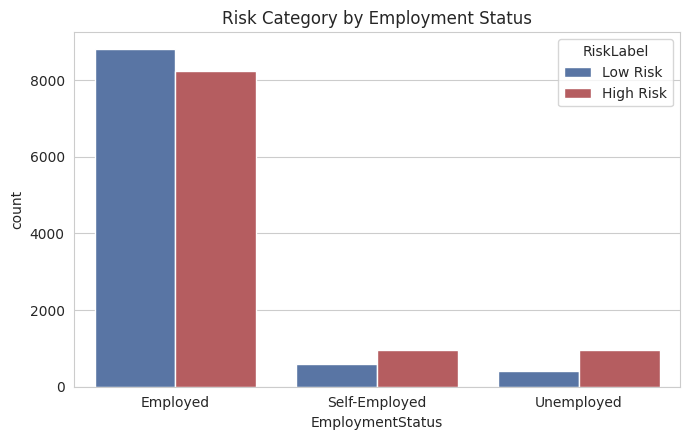

In [20]:
plt.figure(figsize=(7, 4.5))
sns.countplot(x='EmploymentStatus', hue='RiskLabel', data=df, hue_order=order, palette=['#4C72B0', '#C44E52'])
plt.title('Risk Category by Employment Status'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/risk_by_employment.png'); plt.show()

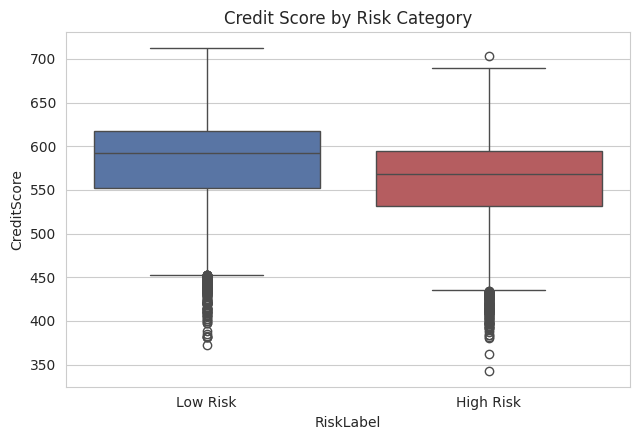

In [21]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x='RiskLabel', y='CreditScore', data=df, order=order, palette=['#4C72B0', '#C44E52'])
plt.title('Credit Score by Risk Category'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/risk_by_credit_score.png'); plt.show()

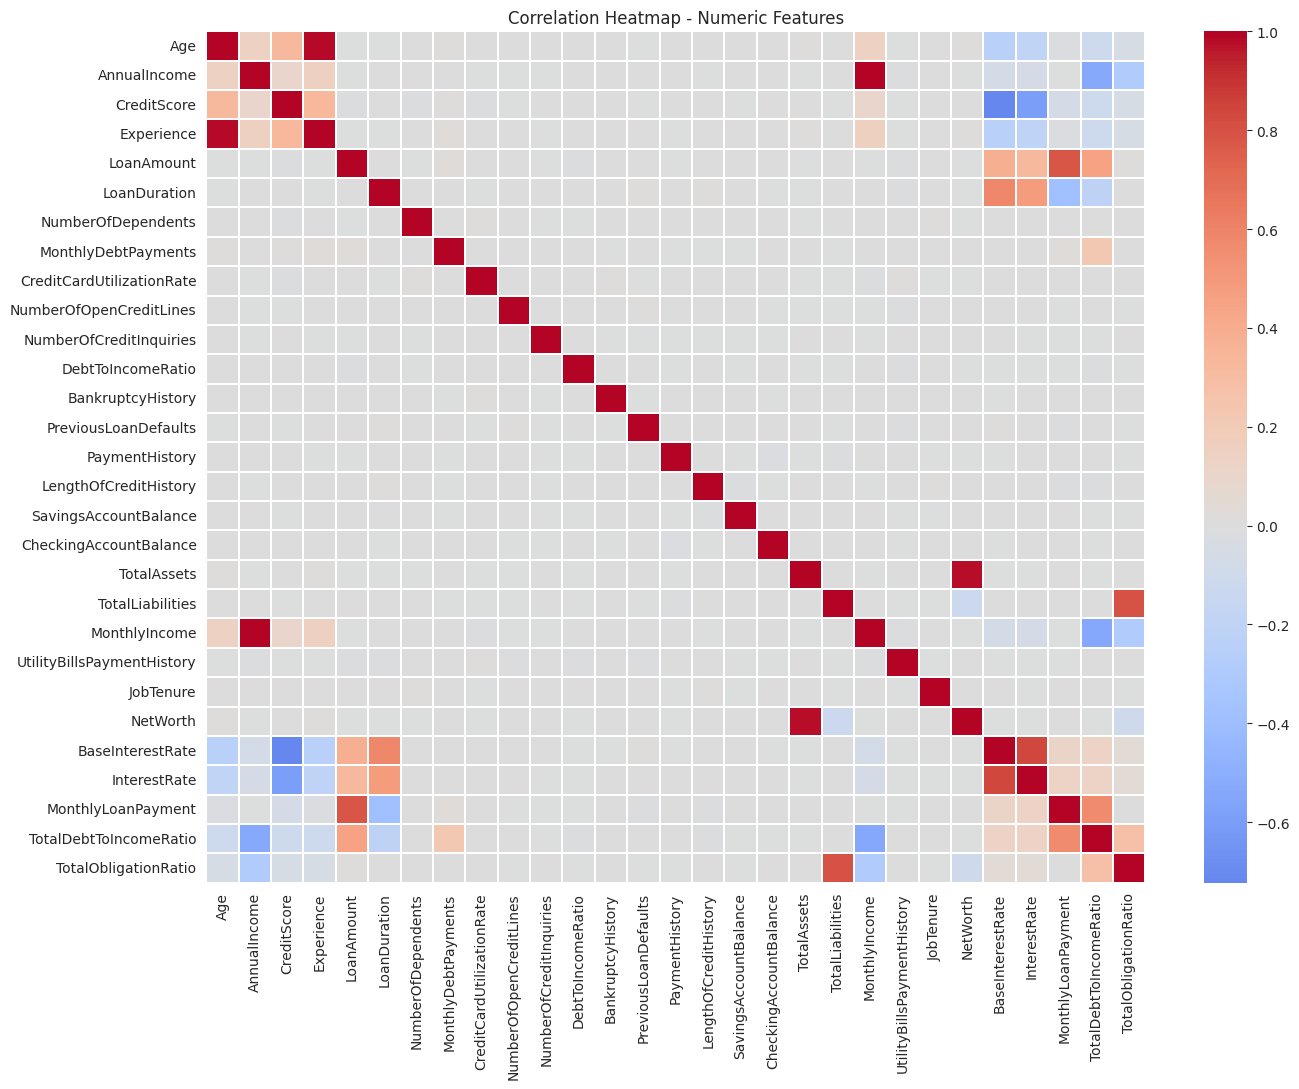

In [22]:
plt.figure(figsize=(14, 11))
corr = df[numeric_cols_all].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap - Numeric Features'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/correlation_heatmap.png'); plt.show()

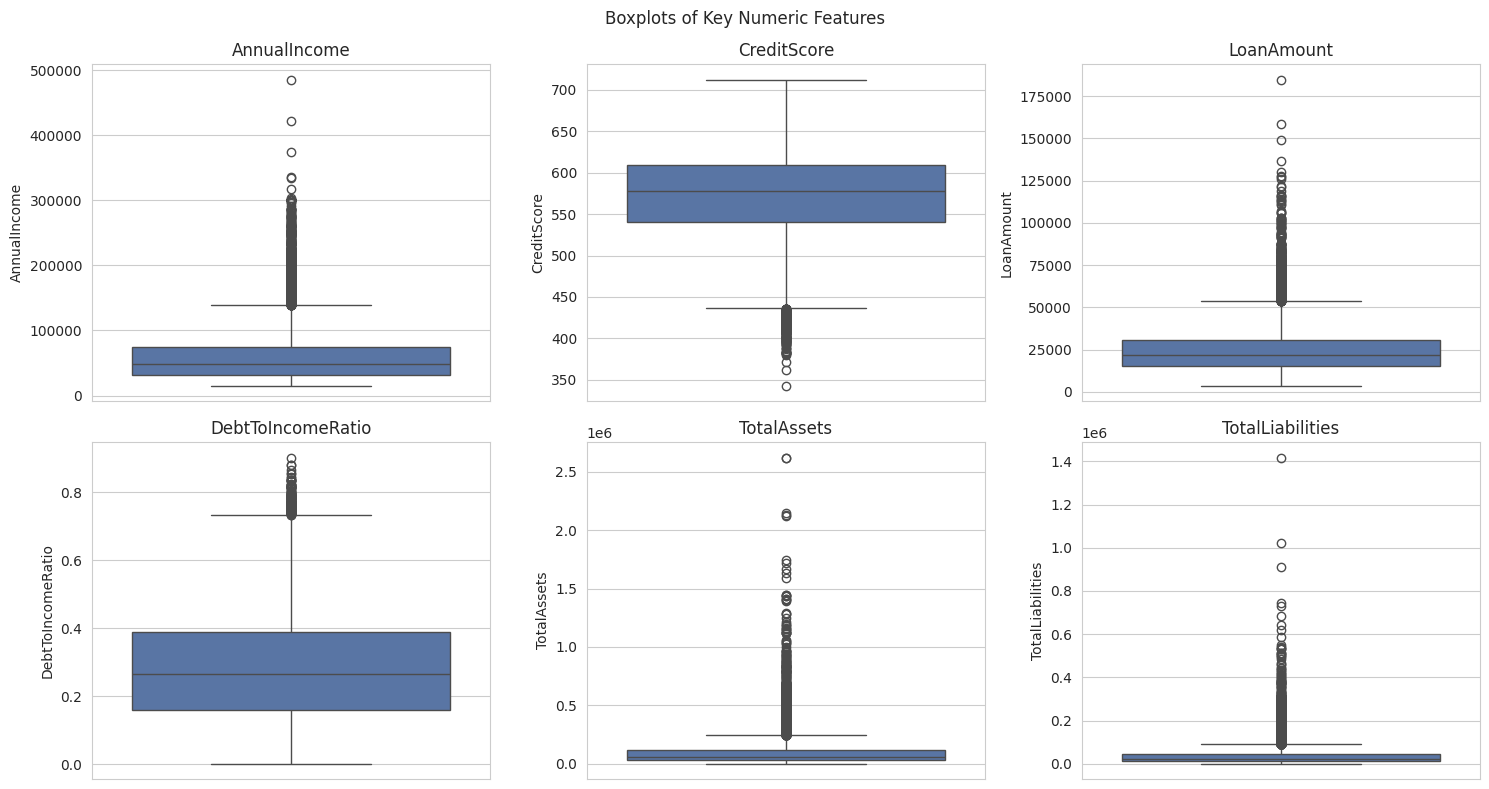

In [23]:
important_num = ['AnnualIncome', 'CreditScore', 'LoanAmount', 'DebtToIncomeRatio', 'TotalAssets', 'TotalLiabilities']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), important_num):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0'); ax.set_title(col)
plt.suptitle('Boxplots of Key Numeric Features'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/numeric_boxplots.png'); plt.show()

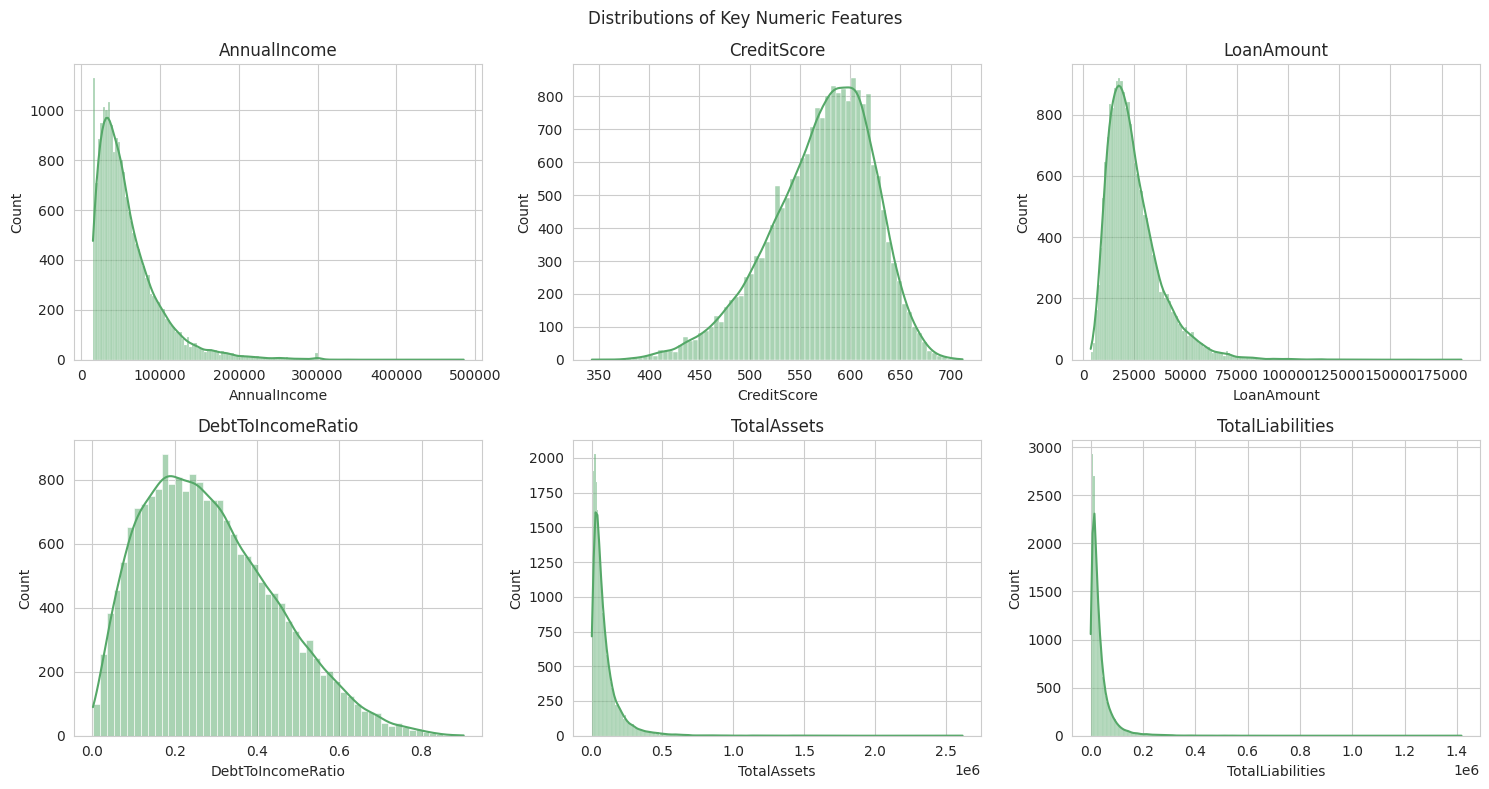

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), important_num):
    sns.histplot(df[col], kde=True, ax=ax, color='#55A868'); ax.set_title(col)
plt.suptitle('Distributions of Key Numeric Features'); plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/numeric_distributions.png'); plt.show()

**Brief observations:** High-risk applicants tend to show lower annual
income and lower credit scores than low-risk applicants (see boxplots
above); the correlation heatmap highlights `DebtToIncomeRatio`,
`TotalDebtToIncomeRatio`, `NetWorth`, `AnnualIncome`/`MonthlyIncome`, and
`BankruptcyHistory` as features most associated with risk — consistent with
the feature-importance results obtained later from the trained model.

## 13. Train/Test Split

80/20 stratified split with a fixed `random_state=42`, performed **before**
any preprocessing, scaling, encoding or SMOTE.

In [25]:
feature_cols = [c for c in df.columns if c not in LEAKY_COLS + DROP_COLS + ['RiskLabel']]
X = df[feature_cols]
y = (df['RiskLabel'] == 'High Risk').astype(int)  # 1 = High Risk, 0 = Low Risk

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

numeric_features = [c for c in numeric_cols_all if c in feature_cols]
categorical_features = [c for c in categorical_cols_all if c in feature_cols]
print('Numeric features used:', numeric_features)
print('Categorical features used:', categorical_features)

Train shape: (16000, 35)  Test shape: (4000, 35)
Numeric features used: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'TotalObligationRatio']
Categorical features used: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'AgeGroup']


## 14. Class Imbalance Analysis

In [26]:
class_counts = y_train.value_counts()
class_pct = y_train.value_counts(normalize=True) * 100
print('Train class counts:\n', class_counts)
print('\nTrain class %:\n', class_pct)
imbalance_ratio = class_counts.max() / class_counts.min()
print('\nImbalance ratio:', imbalance_ratio)
USE_SMOTE = imbalance_ratio > 1.5
print('Use SMOTE:', USE_SMOTE)

Train class counts:
 RiskLabel
1    8134
0    7866
Name: count, dtype: int64

Train class %:
 RiskLabel
1    50.8375
0    49.1625
Name: proportion, dtype: float64

Imbalance ratio: 1.0340706839562674
Use SMOTE: False


Because the target was constructed with a **median split**, the classes
are naturally close to balanced (~50/50 in the training set, imbalance ratio
~1.03). This is **not** a severe imbalance, so we do **not** apply SMOTE —
using it here would be artificial oversampling for a problem that does not
need it. This decision is confirmed programmatically above (`USE_SMOTE`).

## 15. Model Training

We build one shared `ColumnTransformer` (median imputation + scaling for
numeric, most-frequent imputation + one-hot encoding for categorical) and
wrap each of the four required models in an `imblearn` `Pipeline`
(so SMOTE, if used, would be correctly scoped to training folds only).

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

def make_pipeline(model, use_smote):
    steps = [('preprocessor', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
    steps.append(('classifier', model))
    return ImbPipeline(steps=steps)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
}

## 16. Baseline Model Comparison

In [28]:
def evaluate(pipe, X_te, y_te):
    preds = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:, 1]
    return {
        'Accuracy': accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds),
        'Recall': recall_score(y_te, preds),
        'F1 Score': f1_score(y_te, preds),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }

baseline_results = []
baseline_pipes = {}
for name, model in models.items():
    pipe = make_pipeline(model, USE_SMOTE)
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_test, y_test)
    metrics['Model'] = name
    baseline_results.append(metrics)
    baseline_pipes[name] = pipe

comparison_df = pd.DataFrame(baseline_results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
comparison_df.to_csv('../outputs/model_comparison.csv', index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.87475,0.877029,0.876598,0.876813,0.946502
1,Random Forest,0.91250,0.922267,0.904130,0.913108,0.976022
2,Gradient Boosting,0.93800,0.944279,0.933137,0.938675,0.983973
3,XGBoost,0.94900,0.948529,0.951327,0.949926,0.990626


## 17. Hyperparameter Tuning

`RandomizedSearchCV` with 5-fold stratified cross-validation, scoring on
**F1** (balances precision and recall — both matter here since the target is
balanced but misclassifying either class has a real cost). The test set is
never used during tuning.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced'],
    },
    'Random Forest': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [None, 8, 12, 16],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__class_weight': [None, 'balanced'],
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [2, 3, 4],
        'classifier__min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [3, 4, 5, 6],
        'classifier__subsample': [0.7, 0.8, 1.0],
        'classifier__colsample_bytree': [0.7, 0.8, 1.0],
        'classifier__reg_lambda': [0.5, 1.0, 2.0],
    },
}

tuned_pipes = {}
best_params_report = {}
for name, model in models.items():
    pipe = make_pipeline(model, USE_SMOTE)
    search = RandomizedSearchCV(
        pipe, param_distributions=param_grids[name], n_iter=15, scoring='f1',
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_pipes[name] = search.best_estimator_
    best_params_report[name] = search.best_params_
    print(name, '-> best CV F1:', round(search.best_score_, 4), '| best params:', search.best_params_)

Logistic Regression -> best CV F1: 0.8728 | best params: {'classifier__class_weight': None, 'classifier__C': 1}


Random Forest -> best CV F1: 0.9165 | best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}


Gradient Boosting -> best CV F1: 0.9523 | best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}


XGBoost -> best CV F1: 0.9518 | best params: {'classifier__subsample': 0.8, 'classifier__reg_lambda': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}


## 18. Final Model Evaluation (tuned models, on held-out test set)

In [30]:
tuned_results = []
for name, pipe in tuned_pipes.items():
    metrics = evaluate(pipe, X_test, y_test)
    metrics['Model'] = name
    tuned_results.append(metrics)
tuned_comparison_df = pd.DataFrame(tuned_results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
tuned_comparison_df.to_csv('../outputs/model_comparison_tuned.csv', index=False)
tuned_comparison_df.sort_values('F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.95050,0.950884,0.951819,0.951351,0.990676
3,XGBoost,0.94950,0.948580,0.952311,0.950442,0.991425
1,Random Forest,0.91450,0.921315,0.909538,0.915388,0.976911
0,Logistic Regression,0.87475,0.877029,0.876598,0.876813,0.946502


## 19. Confusion Matrix

Selected best model: Gradient Boosting


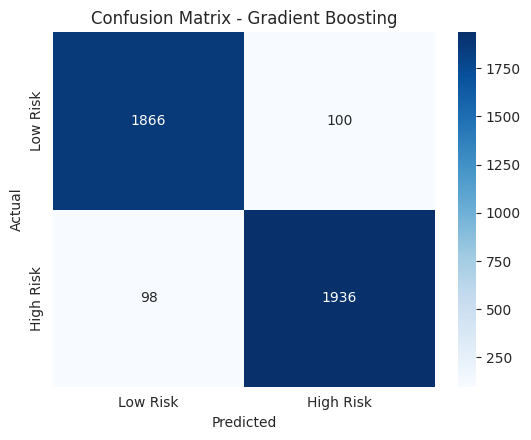

TN, FP, FN, TP: [1866  100   98 1936]


In [31]:
ranked = tuned_comparison_df.sort_values(['F1 Score', 'ROC-AUC'], ascending=False)
best_model_name = ranked.iloc[0]['Model']
best_pipe = tuned_pipes[best_model_name]
print('Selected best model:', best_model_name)

preds = best_pipe.predict(X_test)
proba = best_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title(f'Confusion Matrix - {best_model_name}'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/confusion_matrix.png'); plt.show()
print('TN, FP, FN, TP:', cm.ravel())

## 20. ROC Curve

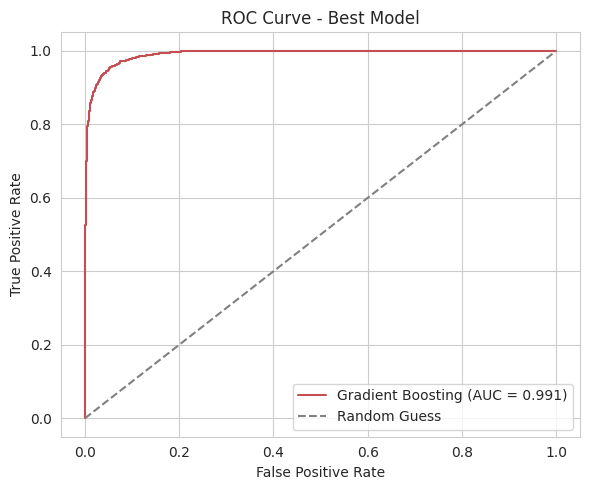

In [32]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc_val = roc_auc_score(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_val:.3f})', color='#C44E52')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve - Best Model')
plt.legend(); plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/roc_curve.png'); plt.show()

## 21. Feature Importance

Feature importance indicates which variables contributed most to the
model's predictions on average; it does **not** prove causation.

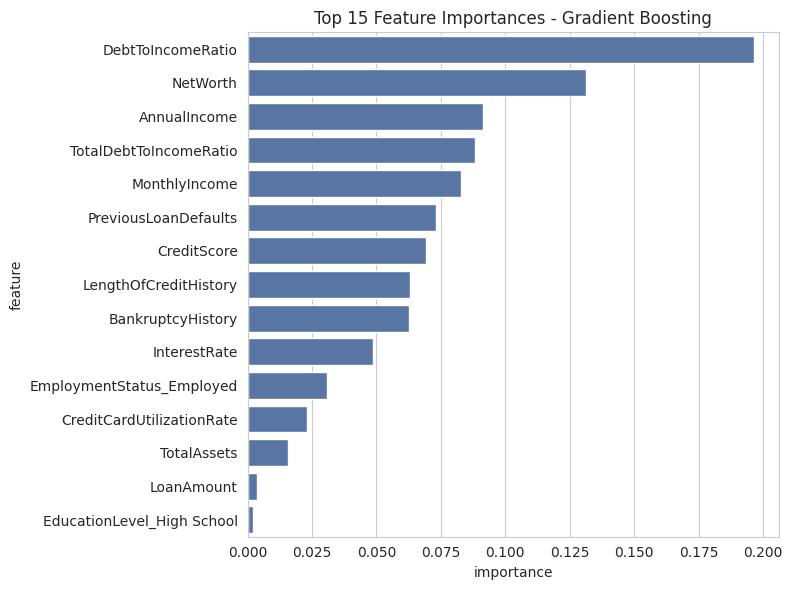

,feature,importance
11,DebtToIncomeRatio,0.196395
23,NetWorth,0.131479
1,AnnualIncome,0.091177
27,TotalDebtToIncomeRatio,0.088119
20,MonthlyIncome,0.082738
13,PreviousLoanDefaults,0.073187
2,CreditScore,0.069182
15,LengthOfCreditHistory,0.062937
12,BankruptcyHistory,0.062616
25,InterestRate,0.048558


In [33]:
def get_feature_names(preprocessor):
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
    return list(numeric_features) + cat_names

fitted_preprocessor = best_pipe.named_steps['preprocessor']
all_feature_names = get_feature_names(fitted_preprocessor)
classifier = best_pipe.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x='importance', y='feature', data=fi_df, color='#4C72B0')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/feature_importance.png'); plt.show()
    display(fi_df)

## 22. Final Model Selection

Selection is based on the actual tuned test-set results above (Section 18),
prioritizing **F1 Score** (balances precision and recall) with **ROC-AUC**
as a tie-breaker, while also considering recall specifically — in credit
risk, failing to flag a genuinely high-risk applicant (a false negative) can
be more costly than an overly cautious false positive. XGBoost was **not**
automatically chosen; the model with the best actual tuned metrics was
selected programmatically (see `ranked` above).

In [34]:
print('FINAL SELECTED MODEL:', best_model_name)
print()
print(ranked.to_string(index=False))
print()
print('Best hyperparameters:', best_params_report[best_model_name])

FINAL SELECTED MODEL: Gradient Boosting

              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
  Gradient Boosting   0.95050   0.950884 0.951819  0.951351 0.990676
            XGBoost   0.94950   0.948580 0.952311  0.950442 0.991425
      Random Forest   0.91450   0.921315 0.909538  0.915388 0.976911
Logistic Regression   0.87475   0.877029 0.876598  0.876813 0.946502

Best hyperparameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}


## 23. Save Final Model

In [35]:
joblib.dump(best_pipe, f'{MODELS_DIR}/credit_risk_model.joblib')

metadata = {
    'best_model_name': best_model_name,
    'risk_median_threshold': float(RISK_MEDIAN),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'feature_cols': feature_cols,
    'best_params': best_params_report[best_model_name],
    'categorical_options': {c: sorted(df[c].astype(str).unique().tolist()) for c in categorical_features},
    'numeric_ranges': {c: {'min': float(df[c].min()), 'max': float(df[c].max()), 'median': float(df[c].median())} for c in numeric_features},
}
with open(f'{MODELS_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:', f'{MODELS_DIR}/credit_risk_model.joblib')
print('Saved:', f'{MODELS_DIR}/metadata.json')

Saved: ../models/credit_risk_model.joblib
Saved: ../models/metadata.json


## 24. Conclusion

**Summary:** Using the `Loan.csv` dataset (20,000 applicants, 36 raw
columns), we constructed a `High Risk` / `Low Risk` target from the
dataset's `RiskScore` (median split), carefully excluding `RiskScore` and
the downstream `LoanApproved` field to avoid leakage. After cleaning
(no missing values / duplicates found), feature engineering
(`TotalObligationRatio`, `AgeGroup`), and EDA, we trained four models
(Logistic Regression, Random Forest, Gradient Boosting, XGBoost) inside
`sklearn`/`imblearn` pipelines, tuned each with `RandomizedSearchCV`
(5-fold CV, scoring=F1), and evaluated all of them on a held-out 20% test
set. The best-performing tuned model (selected on actual F1/ROC-AUC results,
see Section 22) was saved as a single deployable pipeline and served through
a Streamlit application (`app.py`).

**Key limitation:** Because the target is derived from `RiskScore`, which is
itself likely a formula computed from the applicant's financial attributes,
the model is partly learning to approximate that existing scoring formula
rather than an independently observed outcome (e.g. an actual future
default). This is disclosed here and in the README for transparency.

**Learning outcomes:** This project demonstrates practical experience with
data leakage analysis, `ColumnTransformer`/`Pipeline` design, feature
engineering, EDA, handling class balance, cross-validated hyperparameter
tuning, multi-metric model evaluation, model persistence, and deployment via
Streamlit.